In [2]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
sys.path.append('/home/cosweeney/code/Fits/')

from fit_utils import bin_velocities_abs
from scipy.interpolate import RectBivariateSpline
from scipy.integrate import quad_vec
from scipy.stats import t, johnsonsu
from scipy.optimize import curve_fit
import pickle
import scipy

from vel_bias_utils import *

from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
print(cosmo.h, cosmo.Hz(redshift), cosmo.H0*cosmo.Ez(redshift))

import warnings
warnings.filterwarnings("ignore")

sys.path.append('/home/cosweeney/code/Fits/')

import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

with h5.File('/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5', 'r') as pc:
    print(pc.keys(), end=' ')

    tag = np.array(pc['tag'])
    orbit_mask = (tag == 0)
    infall_mask = (tag == 1) 

    hostmvir = np.array(pc['hostmvir'])
    hostrvir = np.array(pc['hostrvir'])

    #Massbins
    print('Minimum M:', hostmvir.min()/1e14, '$10^{14}M_\odot$')
    print('Maximum M:', hostmvir.max()/1e14, '$10^{14}M_\odot$')

    mini=hostmvir.min()
    maxi=1.6e15#pc['hostmvir'].max()

    #Choose Bins: Log-spaced bins between min and max
    massbins = np.logspace( np.log10(mini), np.log10(maxi), 7+1)
    mbins = np.delete(massbins, -2)
    print('massbins:', mbins)

    Rvirs=[]
    Mvirs=[]
    for i in range(len(mbins)-1):
        mmask = (hostmvir>=mbins[i])&(hostmvir<=mbins[i+1])
        orbi_M = hostmvir[mmask&orbit_mask]
        orbi_R = hostrvir[mmask&orbit_mask]
        print(mbins[i]/1e14, mbins[i+1]/1e14)

        Rvirs.append(np.median(orbi_R))
        Mvirs.append(np.median(orbi_M))
    Rvirs=np.array(Rvirs)
    Mvirs=np.array(Mvirs)

# radial bins
r_edges = np.linspace(4, 30, 26+1)
r_cens = (r_edges[1:]+r_edges[:-1])/2.0

zel_xhg = np.fromfile('/spiff/cosweeney/simulations/MDPL2/data/CorrFuncs/zel_xhg.bin')
xhg = h5.File("/spiff/cosweeney/simulations/MDPL2/data/CorrFuncs/xihg_fit_fnl_2.h5")
rxhg = np.array(xhg['rbins'])
exhg = np.array(xhg['r_edges']) 
xihg = np.array(xhg['xi'])

path = "/spiff/cosweeney/simulations/MDPL2/data/models"

with open(path+'RBFint_xi.pkl', 'rb') as f:
    xi_RBF = pickle.load(f)

with open(path+'RBFint_lam.pkl', 'rb') as f: 
    lam_RBF = pickle.load(f) 

0.6777 74.71913613009617 74.71913613009617
<KeysViewHDF5 ['FAS', 'R', 'hostFAS', 'hostM200b', 'hostM200c', 'hostdesid', 'hostid', 'hostmvir', 'hostpid', 'hostrvir', 'hostupid', 'hostvmax', 'hostvrms', 'hostvx', 'hostvy', 'hostvz', 'hostx', 'hosty', 'hostz', 'id', 'r', 'sb_id', 'tag', 'upid', 'v_circ', 'v_r', 'v_tot', 'vlos', 'vx', 'vy', 'vz', 'vz_pec', 'x', 'y', 'z']> Minimum M: 0.80002004 $10^{14}M_\odot$
Maximum M: 22.285 $10^{14}M_\odot$
massbins: [8.00020227e+13 1.22732852e+14 1.88287152e+14 2.88855436e+14
 4.43139440e+14 6.79829904e+14 1.60000000e+15]
0.8000202269281375 1.2273285213892782
1.2273285213892782 1.882871518385872
1.882871518385872 2.888554362556256
2.888554362556256 4.431394401565781
4.431394401565781 6.798299037325463
6.798299037325463 16.000000000000007


In [3]:
#Bin velocities
#vpeclos, R_cens, R_data, rlos_data = bin_velocities_abs('vz_pec', 'R', r_edges, massbins=mbins, return_rvals=True)
vphyslos, R_cens2, R_data1, rlos_data1 = bin_velocities_abs('vlos', 'R', r_edges, massbins=mbins, return_rvals=True)


# Large scales
# vel_path = '/spiff/cosweeney/simulations/MDPL2/data/r_R_rlos_vpeclos_vphyslos_data_mass_100_cyl_update_p.hdf5'

# vpeclos_ls  = []
# vphyslos_ls = []
# rlos_ls = []
# for k, M in enumerate(Mvirs):
#     for i, R in enumerate(r_cens):
#         with h5.File(vel_path, 'r') as hdf:
#             rel_R = hdf[f'R/{str(k)}'][()]
#             rel_rlos = hdf[f'rlos/{str(k)}'][()]
#             vpec = hdf[f'vpeclos/{str(k)}'][()]
#             vphys = hdf[f'vphyslos/{str(k)}'][()]

#         mask = (rel_R >= r_edges[i]) & (rel_R <= r_edges[i+1])

#         vpeclos_ls.append(vpec[mask])
#         vphyslos_ls.append(vphys[mask])
#         rlos_ls.append(rel_rlos[mask])


Number of bins:  156


In [4]:
# Large scales, extnded
vel_path = '/spiff/cosweeney/simulations/MDPL2/data/r_R_rlos_vpeclos_vphyslos_data_mass_80_cyl_6K.hdf5'

vpeclos_ls_ex  = []
vphyslos_ls_ex = []
rlos_ls_ex = []
for k, M in enumerate(Mvirs):
    for i, R in enumerate(r_cens):
        with h5.File(vel_path, 'r') as hdf:
            rel_R = hdf[f'R/{str(k)}'][()]
            rel_rlos = hdf[f'rlos/{str(k)}'][()]
            vpec = hdf[f'vpeclos/{str(k)}'][()]
            vphys = hdf[f'vphyslos/{str(k)}'][()]

        mask = (rel_R >= r_edges[i]) & (rel_R <= r_edges[i+1])

        vpeclos_ls_ex.append(vpec[mask])
        vphyslos_ls_ex.append(vphys[mask])
        rlos_ls_ex.append(rel_rlos[mask])

In [6]:
# with greater initial subbox selection

vel_path = '/spiff/cosweeney/simulations/MDPL2/data/r_R_rlos_vpeclos_vphyslos_data_mass_100_cyl_6K_indmass.hdf5'

vpeclos_ls_exs  = []
vphyslos_ls_exs = []
rlos_ls_exs = []
R_ls_exs = []
M_virs_ls_exs = []
#for k, M in enumerate(Mvirs):
for k, M in enumerate(Mvirs):
    for i, R in enumerate(r_cens):
        with h5.File(vel_path, 'r') as hdf:
            rel_R = hdf[f'R/{str(k)}'][()]
            rel_rlos = hdf[f'rlos/{str(k)}'][()]
            vpec = hdf[f'vpeclos/{str(k)}'][()]
            vphys = hdf[f'vphyslos/{str(k)}'][()]
            m_virs = hdf[f'Mvir/{str(k)}'][()] 

        mask = (rel_R >= r_edges[i]) & (rel_R <= r_edges[i+1])

        vpeclos_ls_exs.append(vpec[mask])
        vphyslos_ls_exs.append(vphys[mask])
        rlos_ls_exs.append(rel_rlos[mask])
        R_ls_exs.append(rel_R[mask])
        M_virs_ls_exs.append(m_virs[mask])

In [160]:
vel_path = '/spiff/cosweeney/simulations/MDPL2/data/r_R_rlos_vpeclos_vphyslos_data_mass_80_cyl_6K.hdf5'

with h5.File(vel_path, 'r') as hdf:
    print(hdf['R'].keys())

<KeysViewHDF5 ['0', '1', '2', '3', '4', '5']>


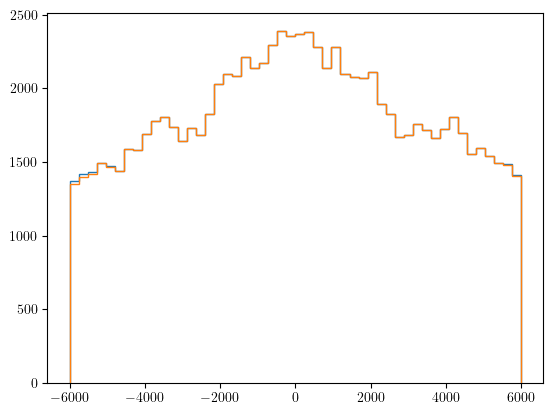

In [174]:
ind = 25
hist1 = plt.hist(vphyslos_ls_exs[ind], bins=50, range=[-6000, 6000], histtype='step' , density=False)
hist2 = plt.hist(vphyslos_ls_ex[ind+5*len(r_cens)], bins=50,range=[-6000, 6000], histtype='step', density=False)

In [30]:
bins = np.linspace(-6000, 6000, 120+1)

vcens_ex = 0.5*(bins[1:]+bins[:-1])

vcens_ex[20]


np.float64(-3950.0)

In [48]:

def P_vphys_R_vec(v_phys, R, M, pars):  
    M = M * 1e14

    h = cosmo.h 
    a = 0.83760
    redshift=1/a-1
    H = h*100*cosmo.Ez(redshift)

    rlos_edges = np.linspace(-40, 40, 40+1)  
    rlos_cens = 0.5*(rlos_edges[1:]+rlos_edges[:-1]) 

    rlos_vals = rlos_cens

    vpec = v_phys[:, None] - a * H * rlos_vals[None, :] / h 

    vpec_data_max = np.max(vpec) #20_000 #4000.0
    print('vpec_data_max:', vpec_data_max)

    vr_e = np.linspace(-vpec_data_max, vpec_data_max, 500+1) 
    vr_grid = 0.5*(vr_e[1:]+vr_e[:-1])

    #print(np.min(vpec), np.max(vpec))

    Pvlos_grid = np.array([P_vlos_R_rlos(vr_grid, R, rlos, M, pars) for rlos in rlos_vals])  


    from scipy.interpolate import interp1d

    Pvlos_interp_list = []

    for j in range(len(rlos_vals)):
        interp_func = interp1d(vr_grid, Pvlos_grid[j], kind='cubic', 
                            bounds_error=False, fill_value=0.0)
        interpolated = interp_func(vpec[:, j])

        Pvlos_interp_list.append(interpolated)

    Pvlos_interp = np.array(Pvlos_interp_list)
    Pvlos_interp = Pvlos_interp.T 

    r3d = np.sqrt(R**2 + rlos_vals**2)
    weight = 0.014 * (cf_inf(r3d, M, cf_pars) + 1)

    integrand = Pvlos_interp * weight[None, :]
    from scipy.integrate import simpson
    P_out = simpson(integrand, x=rlos_vals, axis=1)

    sigma_R = Sigma_inf(R, M, h, cf_pars)
    P_out /= sigma_R

    return P_out / np.sum(P_out*np.diff(v_phys)[0])

#test = P_vphys_R_vec(vcens_ex, 10, 1.0, gal_MAP)

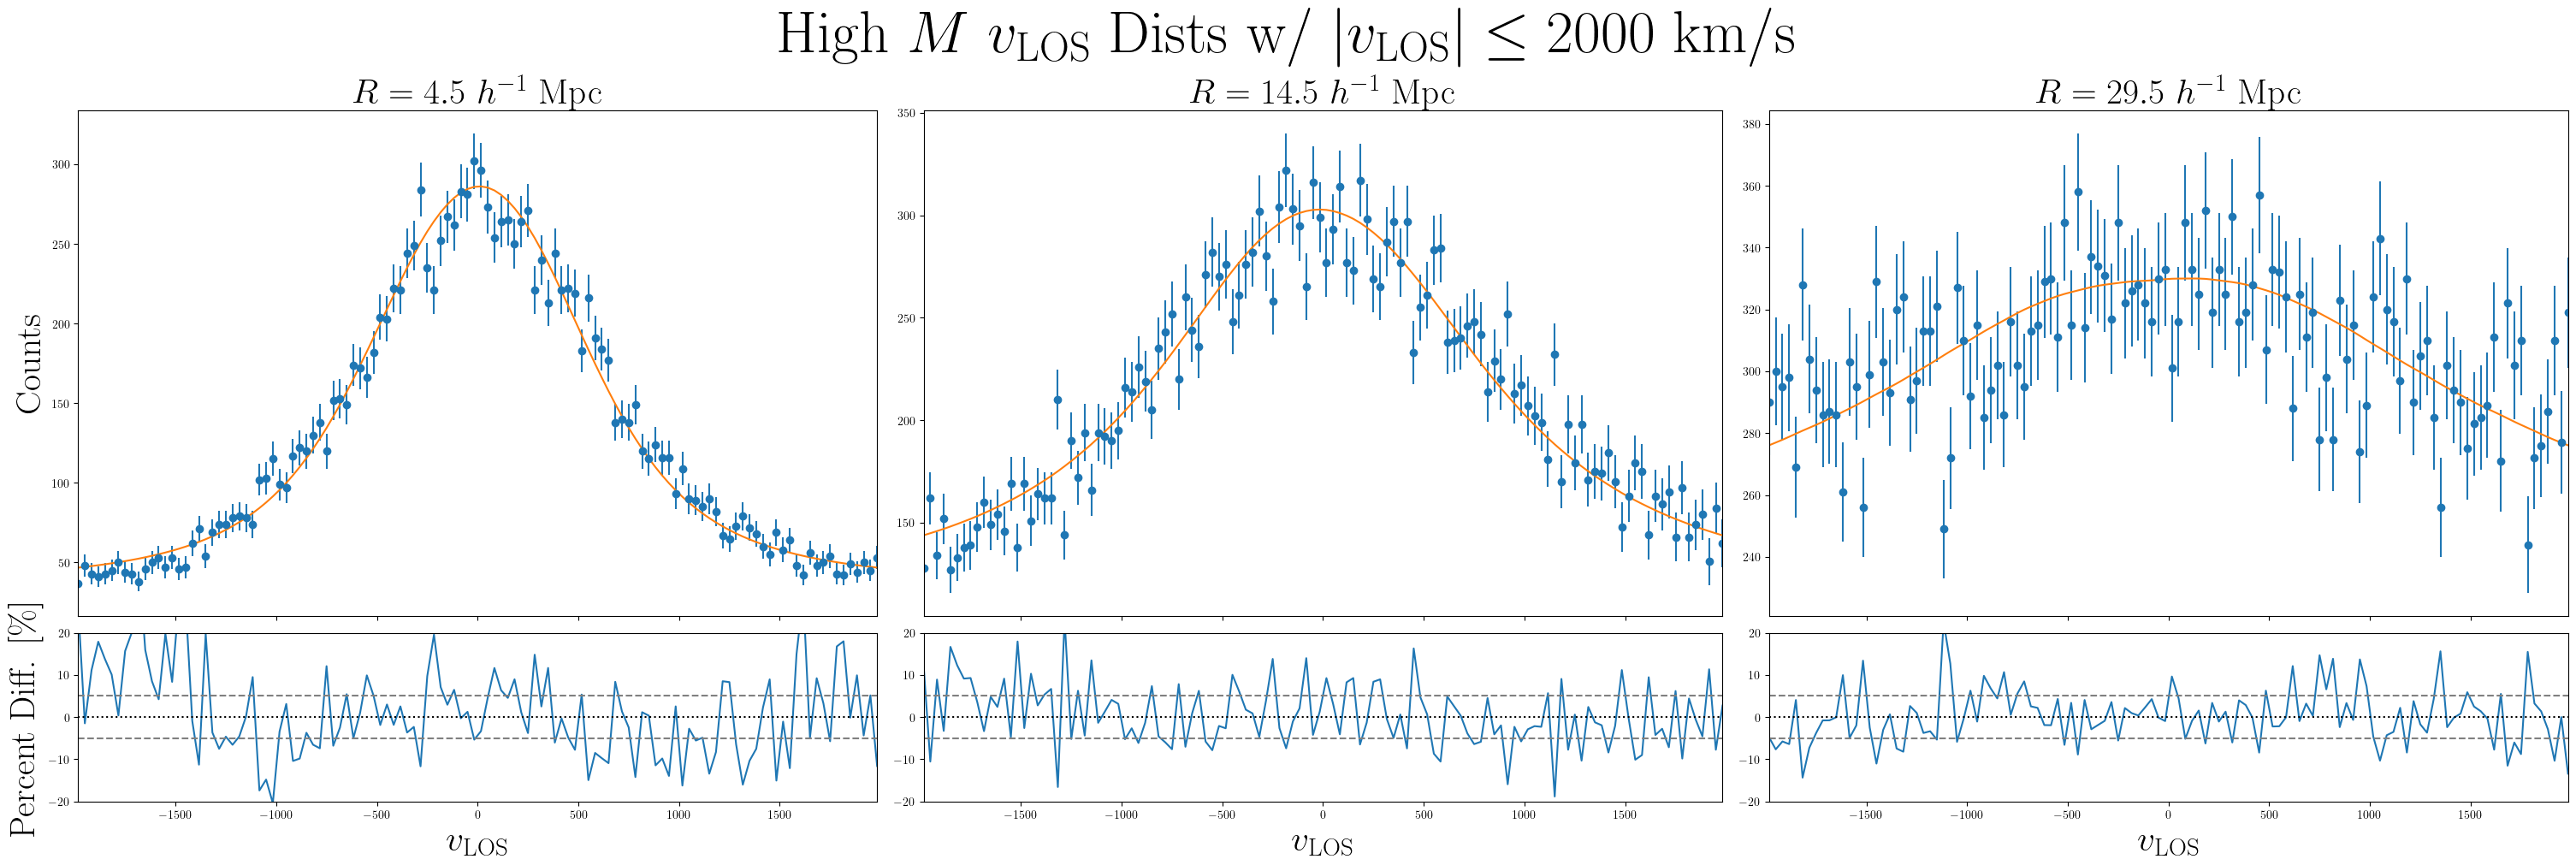

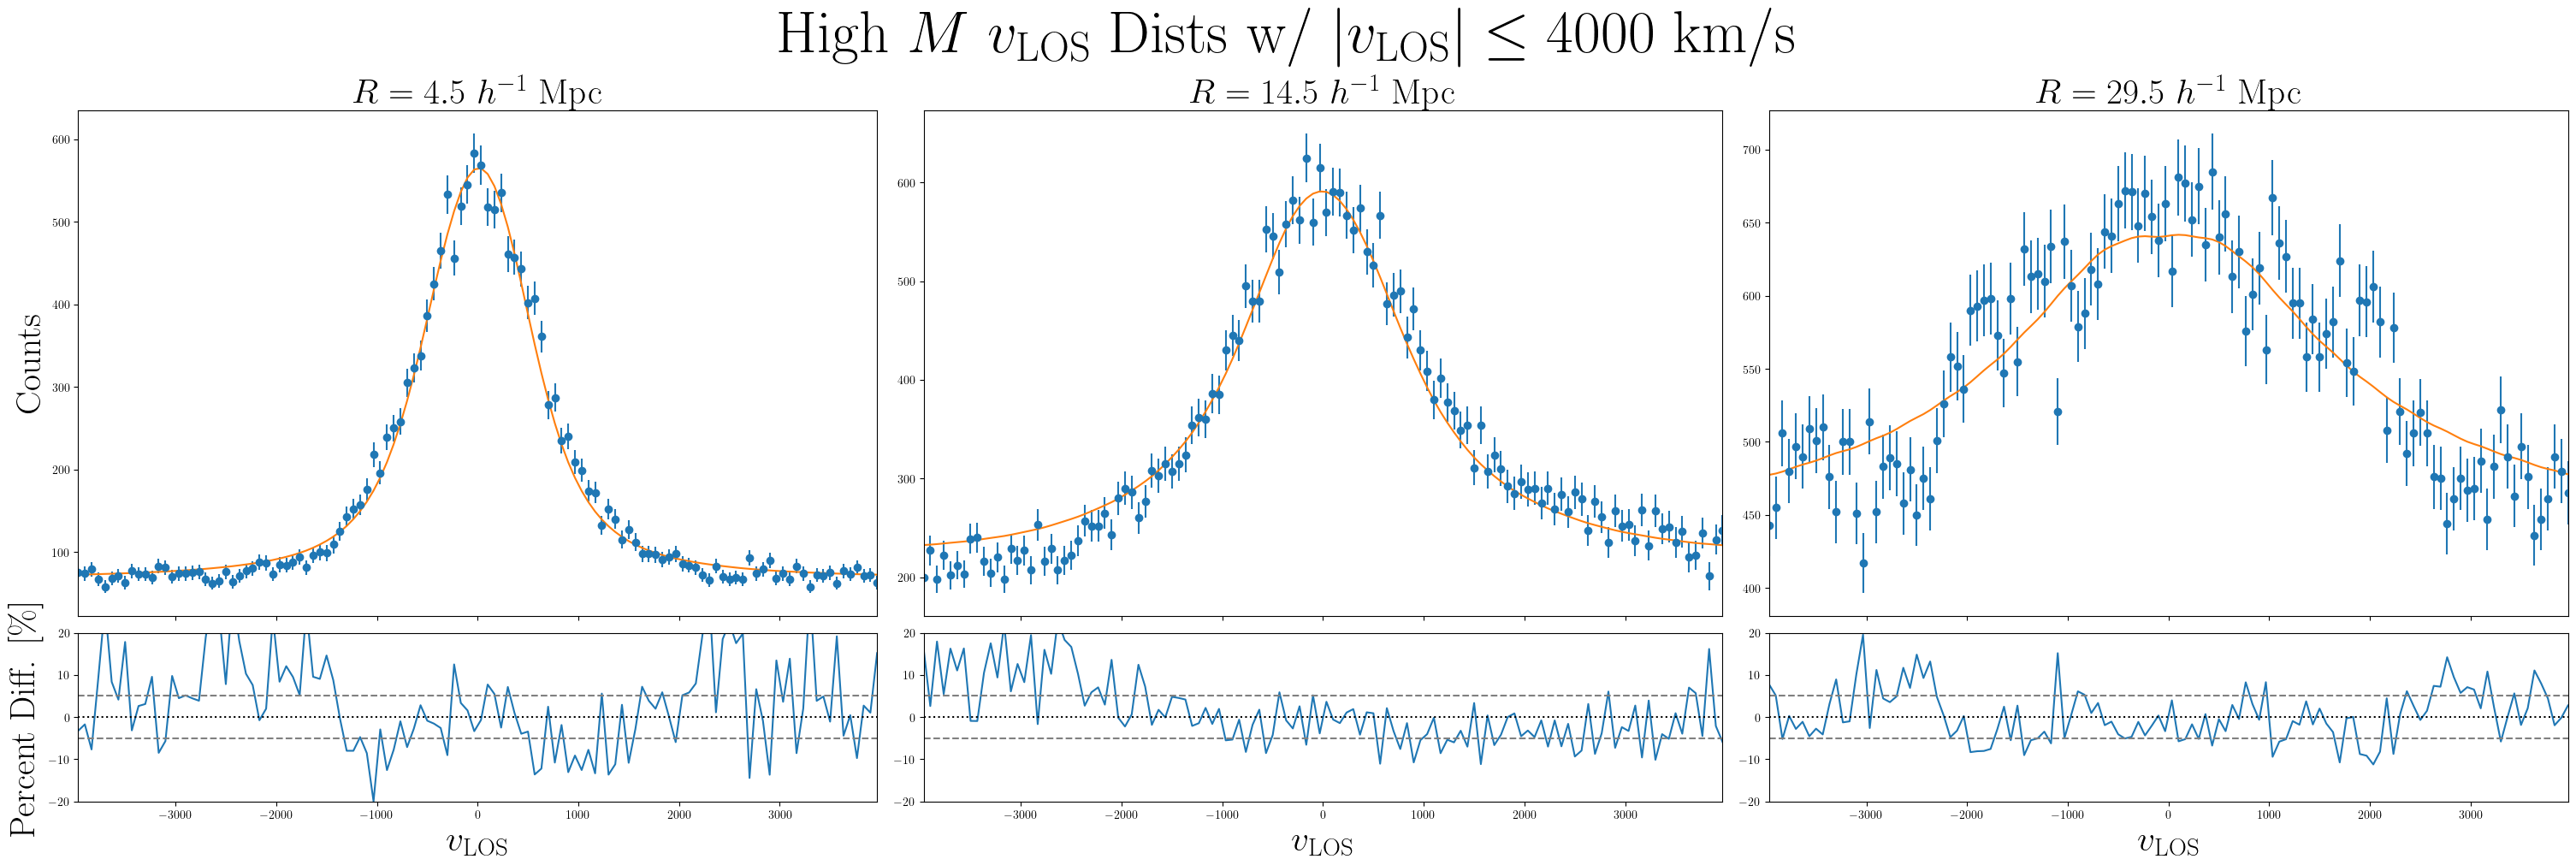

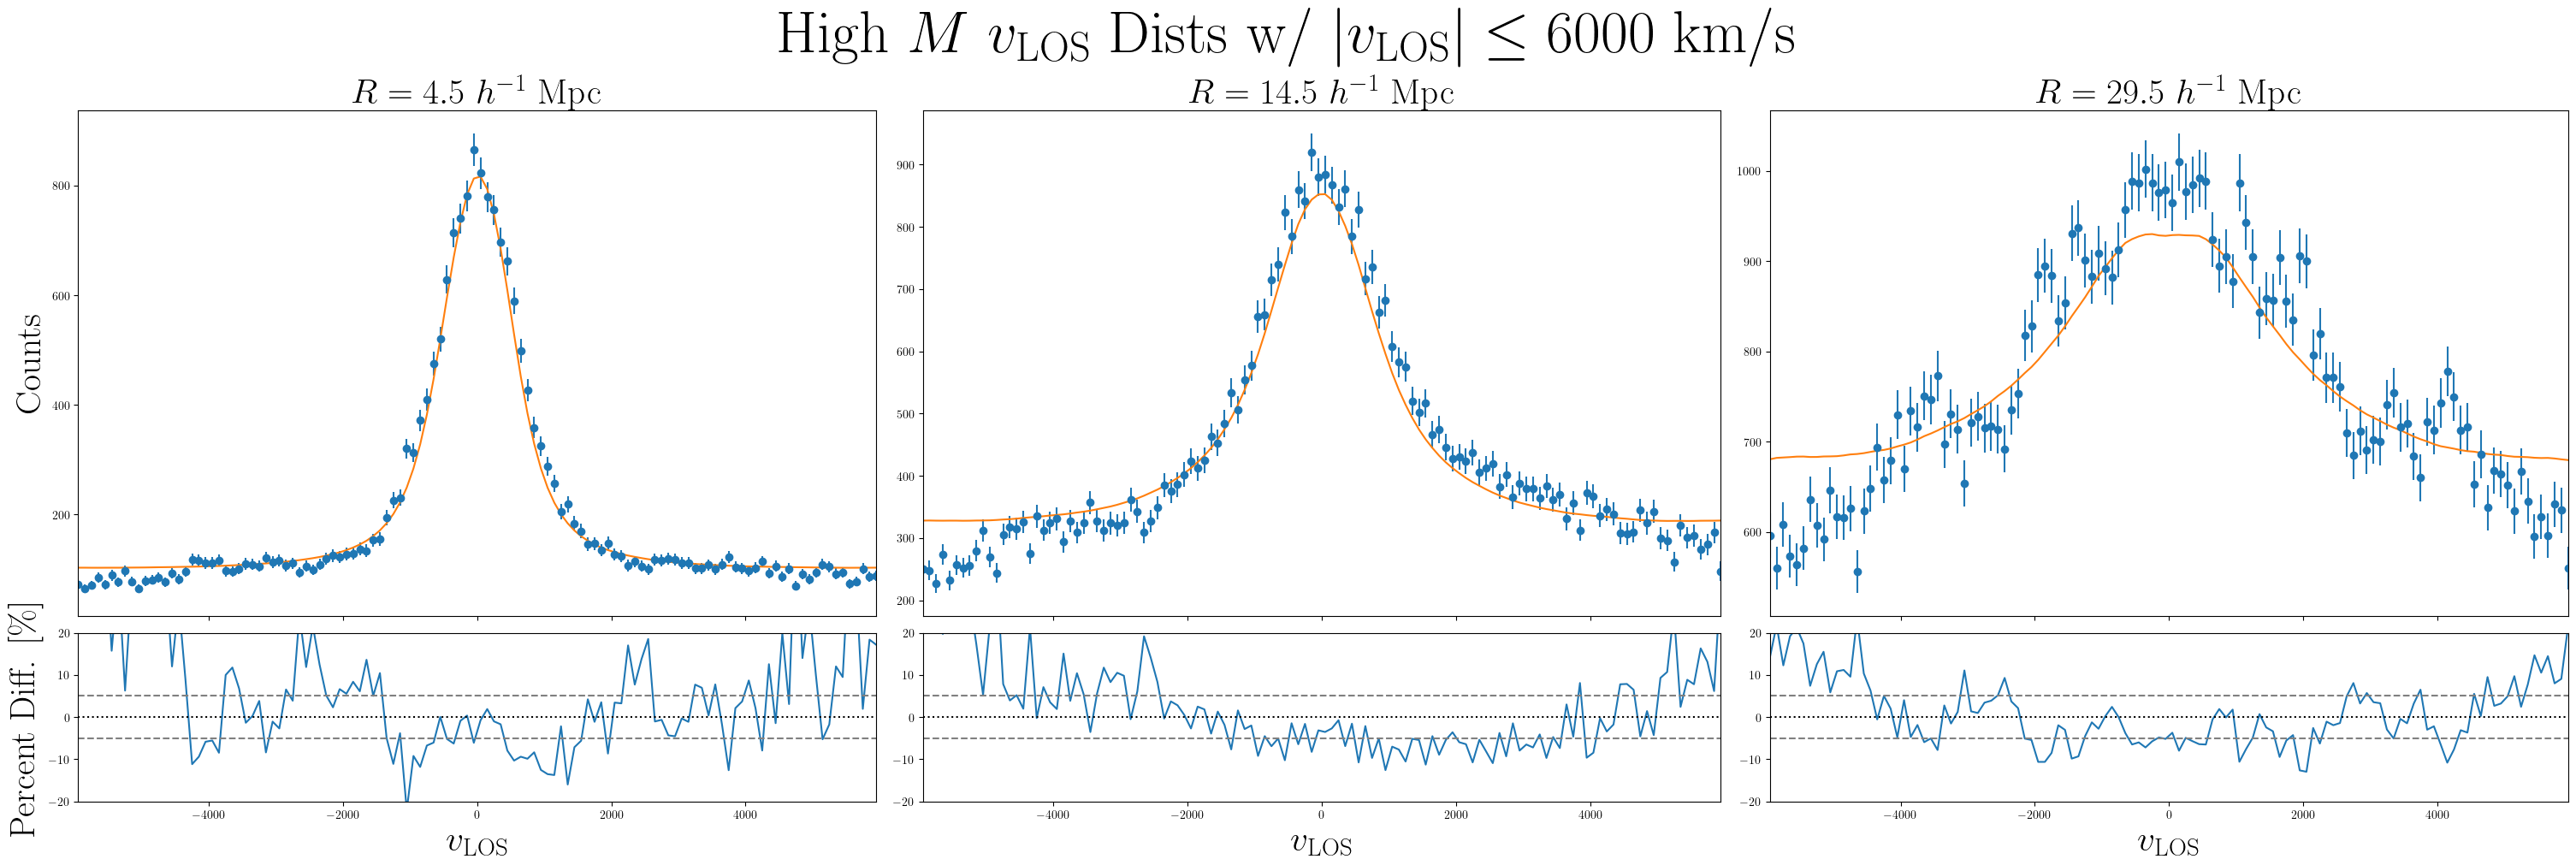

In [7]:
# compare histograms  
mvirs = Mvirs/1e14
bin_num = 120

r_select_inds = [0, 10, 25]
r_select = np.array([r_cens[i] for i in r_select_inds]) 

lims = [2000, 4000, 6000]

for j in range(3):
    for k in range(1):
        k = 5
        fig, ax = plt.subplots(2, len(r_select), figsize=(30, 10), sharex=True, layout='constrained', gridspec_kw={'height_ratios': [3, 1]}) 
        for i, R in enumerate(r_select):

            #index = i + k*len(r_cens)
            hist_2, bins_ex = np.histogram(vphyslos_ls_exs[r_select_inds[i]], bins=bin_num, range=[-lims[j], lims[j]], density=False)

            vcens_ex = 0.5*(bins_ex[1:]+bins_ex[:-1])

            dist = P_vphys_R_vec(vcens_ex, R, mvirs[k], gal_MAP)
            dist = dist / np.sum(dist*np.diff(vcens_ex)[0]) 

            N_avg = np.sum(hist_2)*dist*np.diff(vcens_ex)[0]

            ax[0, i].errorbar(vcens_ex, hist_2, np.sqrt(hist_2), fmt='o', c='C0')#
            ax[0, i].plot(vcens_ex, N_avg, c='C1')# 
            ax[0, i].set_title(r"$R={} \ h^{{-1}}$ Mpc".format(R), fontsize=30)
            ax[0, i].margins(x=0)

            ax[1, i].plot(vcens_ex, (N_avg - hist_2)/hist_2 * 100)
            ax[1, i].axhline(0.0, c='k', ls=':')
            ax[1, i].axhline(5, c='gray', ls='--')
            ax[1, i].axhline(-5, c='gray', ls='--')
            ax[1, i].set_ylim((-20, 20))
            ax[1, i].margins(x=0)
            ax[1, i].set_xlabel(r'$v_{\rm LOS}$', fontsize=30)
        ax[0, 0].set_ylabel(r'Counts', fontsize=30)
        ax[1, 0].set_ylabel(r'Percent Diff. $[\%]$', fontsize=30)
        fig.suptitle(r"High $M$ $v_{{\rm LOS}}$ Dists w/ $|v_{{\rm LOS}}| \leq {}$ km/s".format(lims[j]), fontsize=50) 

In [ ]:
#NOTE: may need to improve sampling of grid for interpolator. Particularly, this appears that we might be able to increase width of inner peak which can affect fits. 


vpec_data_max: 5584.934614844584


vpec_data_max: 5584.934614844584
vpec_data_max: 5584.934614844584


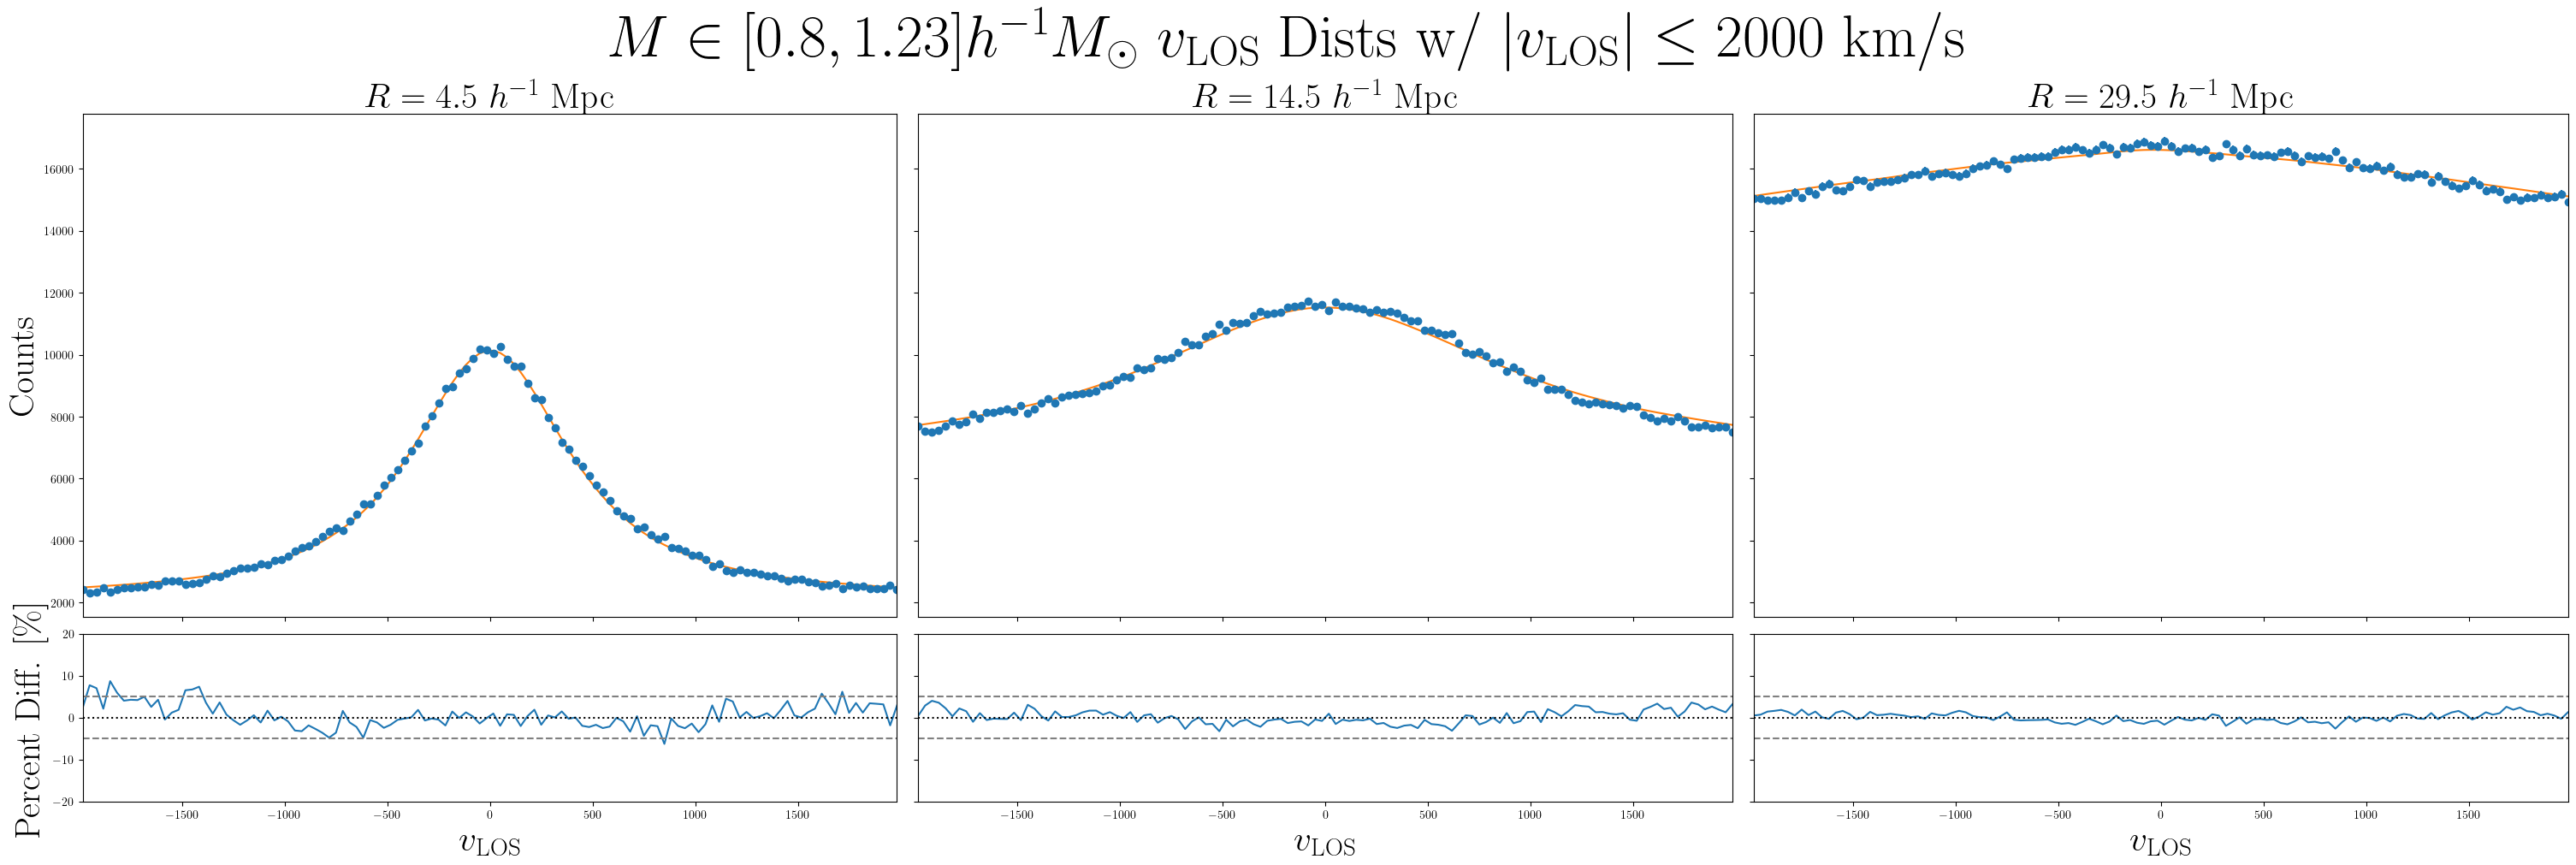

In [49]:
# check quality of "fit" over mass bins with vlos < 2K km/s 

# compare histograms  
mvirs = Mvirs/1e14
bin_num = 120

r_select_inds = [0, 10, 25]
r_select = np.array([r_cens[i] for i in r_select_inds]) 

lims = [2000, 4000, 6000]

#for j in range(1):
j = 0
for k in range(1):
    #k = 5
    fig, ax = plt.subplots(2, len(r_select), figsize=(30, 10), sharex=True, sharey='row', layout='constrained', gridspec_kw={'height_ratios': [3, 1]}) 
    for i, R in enumerate(r_select):

        index = r_select_inds[i] + k*len(r_cens)
        hist_2, bins_ex = np.histogram(vphyslos_ls_exs[index], bins=bin_num, range=[-lims[j], lims[j]], density=False)

        vcens_ex = 0.5*(bins_ex[1:]+bins_ex[:-1])

        dist = P_vphys_R_vec(vcens_ex, R, mvirs[k], gal_MAP)
        dist = dist / np.sum(dist*np.diff(vcens_ex)[0]) 

        N_avg = np.sum(hist_2)*dist*np.diff(vcens_ex)[0]

        ax[0, i].errorbar(vcens_ex, hist_2, np.sqrt(hist_2), fmt='o', c=f'C{str(k)}') #
        ax[0, i].plot(vcens_ex, N_avg, c='C1')# 
        ax[0, i].set_title(r"$R={} \ h^{{-1}}$ Mpc".format(R), fontsize=30)
        ax[0, i].margins(x=0)

        ax[1, i].plot(vcens_ex, (N_avg - hist_2)/hist_2 * 100)
        ax[1, i].axhline(0.0, c='k', ls=':')
        ax[1, i].axhline(5, c='gray', ls='--')
        ax[1, i].axhline(-5, c='gray', ls='--')
        ax[1, i].set_ylim((-20, 20))
        ax[1, i].margins(x=0)
        ax[1, i].set_xlabel(r'$v_{\rm LOS}$', fontsize=30)
    ax[0, 0].set_ylabel(r'Counts', fontsize=30)
    ax[1, 0].set_ylabel(r'Percent Diff. $[\%]$', fontsize=30)
    fig.suptitle(r"$M\in[{}, {}] h^{{-1}}M_\odot$ $v_{{\rm LOS}}$ Dists w/ $|v_{{\rm LOS}}| \leq {}$ km/s".format(round(mbins[k]/1e14, 2), round(mbins[k+1]/1e14, 2), lims[j]), fontsize=50) 

vpec_data_max: 5554.15169790859


Text(0, 0.5, 'Percent Diff. $[\\%]$')

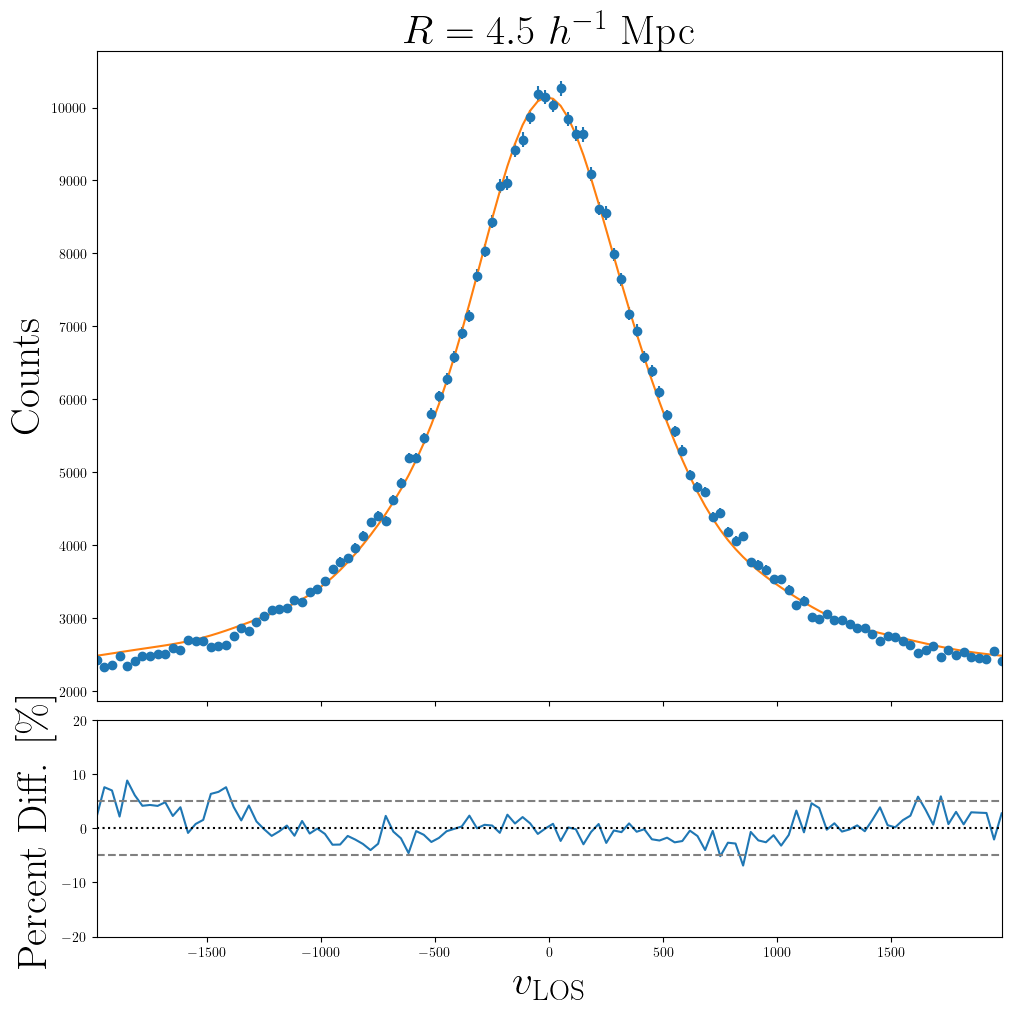

In [44]:
# single plot
i = 0
k = 0
j=0

fig, ax = plt.subplots(2, 1, figsize=(10, 10), sharex=True, layout='constrained', gridspec_kw={'height_ratios': [3, 1]}) 

index = r_select_inds[i] + k*len(r_cens)
hist_2, bins_ex = np.histogram(vphyslos_ls_exs[index], bins=bin_num, range=[-lims[j], lims[j]], density=False)

vcens_ex = 0.5*(bins_ex[1:]+bins_ex[:-1])

dist = P_vphys_R_vec(vcens_ex, r_select[i], mvirs[k], gal_MAP)
dist = dist / np.sum(dist*np.diff(vcens_ex)[0]) 

N_avg = np.sum(hist_2)*dist*np.diff(vcens_ex)[0]

ax[0].errorbar(vcens_ex, hist_2, np.sqrt(hist_2), fmt='o', c=f'C{str(k)}') #
ax[0].plot(vcens_ex, N_avg, c='C1')# 
ax[0].set_title(r"$R={} \ h^{{-1}}$ Mpc".format(r_select[i]), fontsize=30)
ax[0].margins(x=0)

ax[1].plot(vcens_ex, (N_avg - hist_2)/hist_2 * 100)
ax[1].axhline(0.0, c='k', ls=':')
ax[1].axhline(5, c='gray', ls='--')
ax[1].axhline(-5, c='gray', ls='--')
ax[1].set_ylim((-20, 20))
ax[1].margins(x=0)
ax[1].set_xlabel(r'$v_{\rm LOS}$', fontsize=30)
ax[0].set_ylabel(r'Counts', fontsize=30)
ax[1].set_ylabel(r'Percent Diff. $[\%]$', fontsize=30)

In [26]:
65*40

2600

In [8]:
def joint_dist_samples(N, r, M, pars): 
    """Samples of the smooth model for 
    the joint distribution
    P(v_r, v_t | r, M). 

    This is the product of the marginal 
    radial velocity distribution and the 
    conditional tangential velocity 
    distribution:
    
    P(v_r, v_t | r, M) = P(v_r | r, M)P(v_t | v_r, r, M)  

    Args:
        v_r (np.ndarray): radial velocity bin centers. 
        v_t (np.ndarray): tangential velocity bin centers.
        r (float): radial distance bin center.
        pars (np.ndarray): parameters defining radial dependence.
    """

    vrpp, vrps, vrsp, vrss, srpp, srps, srsp, srss, delta_m, delta_b, \
        s_c, s_qm, s_qb, s_mmm, s_mmb, s_mbm, s_mbb, s_0mm, s_0mb = pars

    # Mass dependence
    M_pivot = 1e14 # M_sun
    vr_p = -plaw( M / M_pivot, vrpp, vrps)
    vr_s = -plaw( M / M_pivot, vrsp, vrss)

    sr_p = plaw( M / M_pivot, srpp, srps)
    sr_s = -plaw( M / M_pivot, srsp, srss)

    r_pivot = 10 # radial pivot, 10 h^-1 Mpc

    sr_0 = 213027 # variance limit as r -> 00, km^2 s^-2

    # Radial dependence
    peak = plaw(r / r_pivot , vr_p, vr_s)
    variance = plaw(r / r_pivot, sr_p, sr_s) + sr_0  

    xi = xi_RBF(np.column_stack([peak, variance]))[0] # interpolators
    lam = lam_RBF(np.column_stack([peak, variance]))[0]

    gam = 0.00078 * xi + 0.58599 # JSU skew, kurtosis 
    delt = 0.00209 * lam + 0.28703 + line(M / M_pivot, delta_m, delta_b)

    rad_samples = johnsonsu.rvs(a=gam, b=delt, loc=xi, scale=lam, size=N)

    mask1 = rad_samples > -2_000
    mask2 = ~mask1 #(np.abs(rad_samples) < 3000)

    dof = 5 # degrees of freedom, "shape" parameter
    s_0p = 48 # h^-1 Mpc, transition of sigma_vt^2 minimum to a constant
    s_0c = 105_000 # km^2 s^-2, minimum value as r -> 00 
    
    # Mass dependence 
    s_q = plaw( M / M_pivot, s_qm, s_qb)
    s_mm = line( M / M_pivot, s_mmm, s_mmb)
    s_mb = line( M / M_pivot, s_mbm, s_mbb)
    s_0m = line( M / M_pivot, s_0mm, s_0mb)


    s_m = s_mm / r + s_mb
    s_0 = s_0m * np.log( 1 + np.exp( - (r - s_0p))) + s_0c 

    variance = np.zeros_like(rad_samples)
    variance[mask1] = s_c * ( rad_samples[mask1] - s_m ) ** 3 + s_q * ( rad_samples[mask1] - s_m ) ** 2 + s_0

    test_vr = np.linspace(-2000, -1000, 100)
    p, _ = curve_fit(line, test_vr, s_c * ( test_vr - s_m ) ** 3 + s_q * ( test_vr - s_m ) ** 2 + s_0)
    variance[mask2] = line(rad_samples[mask2], p[0], p[1])

    # variance = np.zeros_like(rad_samples[mask])

    # for i, rad_sample in enumerate(rad_samples[mask]):
    #     if rad_sample > -2_000:
    #         var = s_c * ( rad_sample - s_m ) ** 3 + s_q * ( rad_sample - s_m ) ** 2 + s_0
    #         variance[i] = var
    #     else:
    #         var = s_q * ( rad_sample - s_m ) ** 2 + s_0
    #         variance[i] = var

    scale = np.sqrt( variance )


    tan_samples = t.rvs(df=dof, scale=scale, size=N) #N - np.sum(~mask)


    return rad_samples, tan_samples, mask1 #[mask]

In [128]:
# Compute v_LOS histograms from model samples. 
# 1st attempt: Generate dist at R using observed N|R, compute v_LOS using appropriate r_LOS.
# response: not quite right. Need to generate dists/samples along LOS?

h = cosmo.h 
a = 0.83760
redshift=1/a-1
H = h*100*cosmo.Ez(redshift)

test_neg = joint_dist_samples(len(vphyslos_ls_ex[10])//2, r_cens[10], Mvirs[0], gal_MAP) 
test_pos = joint_dist_samples(len(vphyslos_ls_ex[10])//2, r_cens[10], Mvirs[0], gal_MAP)
test_pos_vr = test_pos[0]
test_pos_vr = -1*test_pos_vr

test_vr = np.concatenate([test_neg[0], test_pos_vr])
test_vt = np.concatenate([test_neg[1], test_pos[1]])

test = (test_vr, test_vt)

theta_test = np.arctan2(r_cens[10], rlos_ls_ex[10])

cos_test = np.cos(theta_test)
sin_test = np.sin(theta_test)

vpeclos_test = ( test[0]*sin_test[:-1] + test[1]*cos_test[:-1] )

vphyslos_test = vpeclos_test + a*H*rlos_ls_ex[10][:-1] / h

In [154]:
# 2nd attempt: generate samples from each v_LOS that we have: M=M_bin, r=r_sample= sqrt{R_samp^2 + r_los, samp^2}. 

test_vlos = vphyslos_ls_exs[10] 
test_R = R_ls_exs[10]
test_rlos = rlos_ls_exs[10]

samp_vr_vt = np.array([joint_dist_samples(1, r=np.sqrt(r_cens[10]**2 + test_rlos[i]**2), M=Mvirs[0], pars=gal_MAP) for i in range(len(test_vlos))]) # takes ~ 1min to run w/ 52,000 samples


In [ ]:
%%timeit 

joint_dist_samples(1, r=np.sqrt(r_cens[10]**2 + test_rlos[i]**2), M=Mvirs[0], pars=gal_MAP) 

1.42 ms ± 6.63 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [143]:
print(len(np.concatenate(vphyslos))*0.00142/60/60, "hours to generate all model samples")

12.601592777777778 hours to generate all model samples


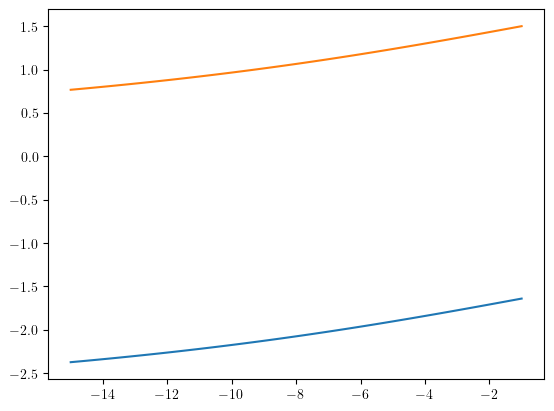

In [117]:
xs = np.linspace(-15, -1, 100)

plt.plot(xs, np.arctan2(-r_cens[10], xs))
plt.plot(xs, np.arctan(-r_cens[10]/xs))

In [155]:
# pos_mask = test_rlos > 0
# samp_vt = np.zeros_like(samp_vr_vt[:, 1, 0])

# samp_vt[pos_mask] = 1 * samp_vr_vt[pos_mask, 0, 0]

h = cosmo.h 
a = 0.83760
redshift=1/a-1
H = h*100*cosmo.Ez(redshift)
theta_test = np.arctan(test_R/test_rlos) #np.arctan2(test_R, test_rlos)

cos_test = np.cos(theta_test)
sin_test = np.sin(theta_test)

vpeclos_test = ( samp_vr_vt[:, 0, 0]*sin_test + samp_vr_vt[:, 1, 0]*cos_test )

vphyslos_test = vpeclos_test + a*H*test_rlos / h

In [31]:
# check samples_parallel: they look good! takes about 2hrs for all but lowest M bin. 
samp_path = '/spiff/cosweeney/simulations/MDPL2/data/Pvlos_models/gal_model_bin_mass_samples_r_4_30.hdf5'

with h5.File(samp_path, 'r') as hdf:
    print(hdf['vphyslos']['0'].keys())
    #print(hdf['vphyslos']['1']['10'][()].shape)
    #for i in range(6):
    #    thist = plt.hist(hdf['vphyslos'][str(i)]['1'][()], bins=bin_num, range=[-4000, 4000], histtype='step', density=False)

<KeysViewHDF5 ['0', '1', '10', '11', '12', '13', '14', '15', '2', '3', '4', '5', '6', '7', '8', '9']>


In [7]:
for i, M in enumerate([Mvirs[0]]):
    print(i)

0


In [8]:
len(r_cens[16:])

10

In [185]:
# 3rd attempt: assign individual halo mass to each halo. How does this look?

test_vlos = vphyslos_ls_exs[10] 
test_R = R_ls_exs[10]
test_rlos = rlos_ls_exs[10]
test_mass = M_virs_ls_exs[10]

samp_vr_vt = np.array([joint_dist_samples(1, r=np.sqrt(test_R[i]**2 + test_rlos[i]**2), M=test_mass[i], pars=gal_MAP) for i in range(len(test_vlos))]) # takes ~ 1min to run w/ 52,000 samples

h = cosmo.h 
a = 0.83760
redshift=1/a-1
H = h*100*cosmo.Ez(redshift)
theta_test = np.arctan(test_R/test_rlos) #np.arctan2(test_R, test_rlos)

cos_test = np.cos(theta_test)
sin_test = np.sin(theta_test)

vpeclos_test_ind = ( samp_vr_vt[:, 0, 0]*sin_test + samp_vr_vt[:, 1, 0]*cos_test )

vphyslos_test_ind = vpeclos_test_ind + a*H*test_rlos / h

In [157]:
mod_test = P_vphys_R_vec(test_vc, r_cens[10], mvirs[5], gal_MAP)
mod_test = mod_test / np.sum(mod_test*np.diff(test_vc)[0])

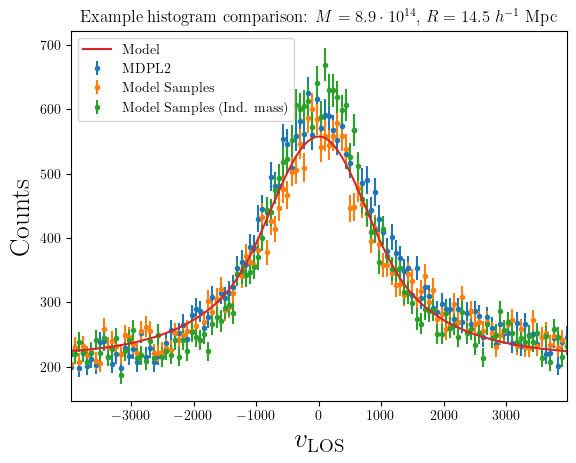

In [198]:
h2 = np.histogram(test_vlos, bins=bin_num, range=[-4000, 4000])
h1 = np.histogram(vphyslos_test, bins=bin_num, range=[-4000, 4000])
h3 = np.histogram(vphyslos_test_ind, bins=bin_num, range=[-4000, 4000])

test_vc = 0.5*(h2[1][1:]+h2[1][:-1])

plt.errorbar(test_vc, h2[0], np.sqrt(h2[0]), fmt='o', c='C0', markersize=3, zorder=0, label='MDPL2')
plt.errorbar(test_vc, h1[0], np.sqrt(h1[0]), fmt='o', c='C1', markersize=3, zorder=0, label='Model Samples')
plt.errorbar(test_vc, h3[0], np.sqrt(h3[0]), fmt='o', c='C2', markersize=3, zorder=0, label='Model Samples (Ind. mass)')

model_counts = np.sum(h1[0])*mod_test*np.diff(test_vc)[0]
plt.plot(test_vc, model_counts, c='C3', label='Model')
#plt.plot(test_vc, np.sum(h2[0])*mod_test*np.diff(test_vc)[0], c='C0')
plt.xlabel(r'$v_{\rm LOS}$', fontsize=20)
plt.ylabel('Counts', fontsize=20)
plt.margins(x=0)
plt.title(f'Example histogram comparison: $M={ 8.9 } \cdot 10^{{14}}$, $R={r_cens[10]} \ h^{{-1}}$ Mpc')
plt.legend()

In [159]:
test_path = samp_path = '/spiff/cosweeney/simulations/MDPL2/data/Pvlos_models/'

with h5.File(samp_path+'test_model.hdf5', 'a') as hdf:
    hdf.create_dataset(name=f'vpeclos/{str(k)}/{str(i)}', data=vpeclos_test, dtype=np.float64)
    hdf.create_dataset(name=f'vphyslos/{str(k)}/{str(i)}', data=vphyslos_test, dtype=np.float64) 

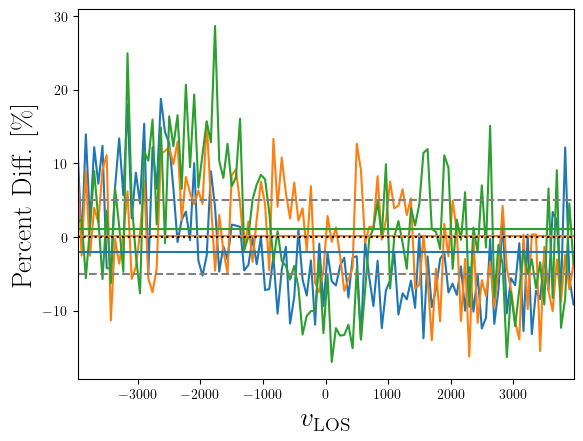

In [201]:
plt.plot(test_vc, (model_counts - h2[0])/h2[0] * 100) 
plt.plot(test_vc, (model_counts - h1[0])/h1[0] * 100) 
plt.plot(test_vc, (model_counts - h3[0])/h3[0] * 100) 

plt.axhline(np.mean((model_counts - h2[0])/h2[0] * 100), c='C0')
plt.axhline(np.mean((model_counts - h1[0])/h1[0] * 100), c='C1')
plt.axhline(np.mean((model_counts - h3[0])/h3[0] * 100), c='C2')

plt.axhline(0, c='k', ls=':')
plt.axhline(5, c='gray', ls='--')
plt.axhline(-5, c='gray', ls='--')
plt.xlabel(r'$v_{\rm LOS}$', fontsize=20)
plt.ylabel('Percent Diff. $[\%]$', fontsize=20)
plt.margins(x=0)

In [ ]:
for k in range(1):
    k = 5
    fig, ax = plt.subplots(2, len(r_select), figsize=(30, 10), sharex=True, layout='constrained', gridspec_kw={'height_ratios': [3, 1]}) 
    for i, R in enumerate(r_select):

        #index = i + k*len(r_cens)
        hist_2, bins_ex = np.histogram(vphyslos_ls_exs[r_select_inds[i]], bins=bin_num, range=[-lims[j], lims[j]], density=False)

        vcens_ex = 0.5*(bins_ex[1:]+bins_ex[:-1])

        dist = P_vphys_R_vec(vcens_ex, R, mvirs[k], gal_MAP)
        dist = dist / np.sum(dist*np.diff(vcens_ex)[0]) 

        N_avg = np.sum(hist_2)*dist*np.diff(vcens_ex)[0]

        ax[0, i].errorbar(vcens_ex, hist_2, np.sqrt(hist_2), fmt='o', c='C0')#
        ax[0, i].plot(vcens_ex, N_avg, c='C1')# 
        ax[0, i].set_title(r"$R={} \ h^{{-1}}$ Mpc".format(R), fontsize=30)
        ax[0, i].margins(x=0)

        ax[1, i].plot(vcens_ex, (N_avg - hist_2)/hist_2 * 100)
        ax[1, i].axhline(0.0, c='k', ls=':')
        ax[1, i].axhline(5, c='gray', ls='--')
        ax[1, i].axhline(-5, c='gray', ls='--')
        ax[1, i].set_ylim((-20, 20))
        ax[1, i].margins(x=0)
        ax[1, i].set_xlabel(r'$v_{\rm LOS}$', fontsize=30)
    ax[0, 0].set_ylabel(r'Counts', fontsize=30)
    ax[1, 0].set_ylabel(r'Percent Diff. $[\%]$', fontsize=30)
    fig.suptitle(r"High $M$ $v_{{\rm LOS}}$ Dists compared to Model and Model Samples", fontsize=50)  